In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score,mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
def add_extra_features(X):
    rooms_per_household = X[:, 3] / X[:, 6]
    bedrooms_per_room = X[:, 4] / X[:, 3]
    population_per_household = X[:, 5] / X[:, 6]
    return np.c_[X, rooms_per_household, bedrooms_per_room, population_per_household]

In [3]:
preprocessor = joblib.load('../artifacts/preprocessor.joblib')
print("Preprocessor loaded successfully!")

Preprocessor loaded successfully!


In [4]:
X_train = pd.read_csv('../data/X_train.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel() # .ravel() converts column vector to 1D array
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

print(f"Loaded X_train shape: {X_train.shape}")

Loaded X_train shape: (16512, 9)


In [5]:
# 1. Linear Regression Pipeline
lin_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# 2. Decision Tree Pipeline
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

# 3. Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [6]:
def display_scores(scores, model_name):
    print(f"--- {model_name} ---")
    print(f"Scores (RMSE): {scores}")
    print(f"Mean RMSE: {scores.mean():.2f}")
    print(f"Standard Deviation: {scores.std():.2f}\n")

In [7]:
# Linear Regression
lin_scores = cross_val_score(lin_reg_pipeline, X_train, y_train, scoring="neg_root_mean_squared_error", cv=5)
display_scores(-lin_scores, "Linear Regression")

--- Linear Regression ---
Scores (RMSE): [70565.3290004  69454.94473751 70676.5540419  69258.97046457
 72148.10972441]
Mean RMSE: 70420.78
Standard Deviation: 1034.66



In [8]:
# Decision Tree
tree_scores = cross_val_score(tree_pipeline, X_train, y_train, scoring="neg_root_mean_squared_error", cv=5)
display_scores(-tree_scores, "Decision Tree")

--- Decision Tree ---
Scores (RMSE): [75624.86244393 76262.53234044 77050.51365496 73525.26569769
 74688.61876018]
Mean RMSE: 75430.36
Standard Deviation: 1227.58



In [9]:
# Random Forest
rf_scores = cross_val_score(rf_pipeline, X_train, y_train, scoring="neg_root_mean_squared_error", cv=5)
display_scores(-rf_scores, "Random Forest")

--- Random Forest ---
Scores (RMSE): [54382.56138147 55372.80542678 54465.21099708 53895.35886173
 54755.8239511 ]
Mean RMSE: 54574.35
Standard Deviation: 485.84



In [10]:
param_grid = [
    {'model__n_estimators': [50, 100, 200], 'model__max_features': [4, 6, 8]},
    # You can add more parameter grids here if you want to test bootstrap=False, etc.
]

grid_search = GridSearchCV(
    rf_pipeline, 
    param_grid, 
    cv=5, 
    scoring='neg_root_mean_squared_error', 
    return_train_score=True,
    n_jobs=-1 # Uses all available CPU cores for faster training
)

In [11]:
print("Running GridSearchCV... (This may take a minute or two)")
grid_search.fit(X_train, y_train)

Running GridSearchCV... (This may take a minute or two)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('attribs_adder',
                                                                                          FunctionTransformer(func=<function add_extra_features at 0x0000025E17A9DBC0>)),
                                                                                         ('power_scaler',
                                                                                          PowerTransformer())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',...
                                                                          'population',
                                                                          'households',
                                                                          'median_income']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('one_hot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['ocean_proximity'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'model__max_features': [4, 6, 8],
                          'model__n_estimators': [50, 100, 200]}],
             return_train_score=True, scoring='neg_root_mean_squared_error')

In [12]:
print(f"Best Parameters Found: {grid_search.best_params_}")
best_rf_pipeline = grid_search.best_estimator_

Best Parameters Found: {'model__max_features': 6, 'model__n_estimators': 200}


In [13]:
lin_reg_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)

def evaluate_model(pipeline, X_test, y_test):
    predictions = pipeline.predict(X_test)
    rmse = root_mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    mape = mean_absolute_percentage_error(y_test, predictions)
    accuracy_percentage = (1 - mape) * 100
    return predictions, rmse, mae, r2 ,accuracy_percentage

In [14]:
lin_preds, lin_rmse, lin_mae, lin_r2, lin_acc = evaluate_model(lin_reg_pipeline, X_test, y_test)
tree_preds, tree_rmse, tree_mae, tree_r2, tree_acc = evaluate_model(tree_pipeline, X_test, y_test)
rf_preds, rf_rmse, rf_mae, rf_r2, rf_acc = evaluate_model(best_rf_pipeline, X_test, y_test)

In [15]:
print("--- FINAL TEST SET METRICS ---")
print(f"Linear Regression -> RMSE: ${lin_rmse:,.0f} | MAE: ${lin_mae:,.0f} | Accuracy: {lin_acc:.1f}%")
print(f"Decision Tree     -> RMSE: ${tree_rmse:,.0f} | MAE: ${tree_mae:,.0f} | Accuracy: {tree_acc:.1f}%")
print(f"Random Forest     -> RMSE: ${rf_rmse:,.0f} | MAE: ${rf_mae:,.0f} | Accuracy: {rf_acc:.1f}%")

--- FINAL TEST SET METRICS ---
Linear Regression -> RMSE: $72,325 | MAE: $53,524 | Accuracy: 67.1%
Decision Tree     -> RMSE: $78,300 | MAE: $50,567 | Accuracy: 72.1%
Random Forest     -> RMSE: $53,994 | MAE: $36,699 | Accuracy: 79.2%


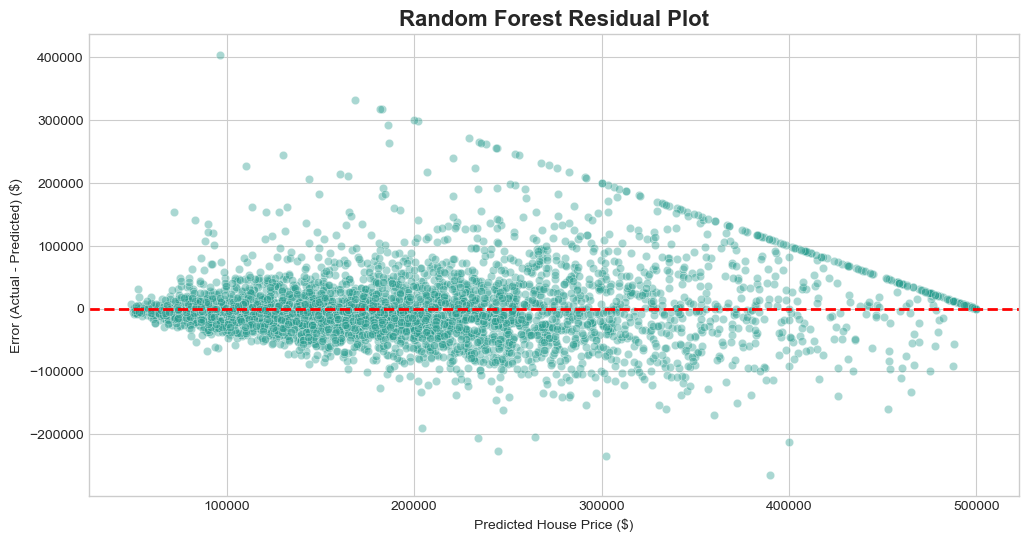

In [16]:
plt.figure(figsize=(12, 6))

# Calculate Residuals (Actual - Predicted)
rf_residuals = y_test - rf_preds

plt_sns.scatterplot(x=rf_preds, y=rf_residuals, alpha=0.4, color='#2A9D8F')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.title("Random Forest Residual Plot", fontsize=16, fontweight='bold')
plt.xlabel("Predicted House Price ($)")
plt.ylabel("Error (Actual - Predicted) ($)")
plt.show()

In [17]:
deployment_package = {
    "Random Forest (Tuned)": {
        "pipeline": best_rf_pipeline,
        "metrics": {"RMSE": rf_rmse, "MAE": rf_mae, "R2": rf_r2, "Accuracy": rf_acc}
    },
    "Linear Regression": {
        "pipeline": lin_reg_pipeline,
        "metrics": {"RMSE": lin_rmse, "MAE": lin_mae, "R2": lin_r2, "Accuracy": lin_acc}
    },
    "Decision Tree": {
        "pipeline": tree_pipeline,
        "metrics": {"RMSE": tree_rmse, "MAE": tree_mae, "R2": tree_r2, "Accuracy": tree_acc}
    }
}



In [18]:
# Change this:
# joblib.dump(deployment_package, '../artifacts/deployment_package.joblib')

# To this:
joblib.dump(deployment_package, '../artifacts/deployment_package.joblib', compress=3)
print("✅ Full Deployment Package saved to artifacts/deployment_package.joblib")
print("We are now ready to build the Streamlit Web Application!")

✅ Full Deployment Package saved to artifacts/deployment_package.joblib
We are now ready to build the Streamlit Web Application!
